In [ ]:
# ============================================================
# CELL 1 — MOBILENETV3
# Environment Setup & Imports
# ============================================================

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V3_Large_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 75)
print("MOBILENETV3 — ENVIRONMENT SETUP")
print("=" * 75)

print(f"\nPyTorch version       : {torch.__version__}")
print(f"CUDA available        : {torch.cuda.is_available()}")
print(f"Device                : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU                   : {torch.cuda.get_device_name(0)}")

print("\nImports completed successfully.")
print("=" * 75)

MOBILENETV3 — ENVIRONMENT SETUP

PyTorch version       : 2.11.0+cu128
CUDA available        : True
Device                : cuda
GPU                   : Tesla T4

Imports completed successfully.


In [ ]:
# ============================================================
# CELL 2 — MOBILENETV3
# Configuration & Dataset Paths
# ============================================================

# ------------------------------------------------------------
# Dataset Path
# ------------------------------------------------------------

DATASET_PATH = "/kaggle/input/indian-painting"

# ------------------------------------------------------------
# Google Drive Save Path
# ------------------------------------------------------------

DRIVE_SAVE_PATH = "/content/drive/MyDrive/Iconography/Implementation/MobileNet-V3"

os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

# ------------------------------------------------------------
# Model Configuration
# ------------------------------------------------------------

MODEL_NAME = "MobileNetV3-Large"

NUM_CLASSES = 8
IMAGE_SIZE = 224

# ------------------------------------------------------------
# DataLoader Configuration
# ------------------------------------------------------------

BATCH_SIZE = 32

NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()

# ------------------------------------------------------------
# Training Configuration
# ------------------------------------------------------------

# Stage 1: Train classifier
STAGE1_EPOCHS = 5

# Stage 2: Fine-tune complete network
STAGE2_EPOCHS = 15

# Total epochs
TOTAL_EPOCHS = STAGE1_EPOCHS + STAGE2_EPOCHS

# ------------------------------------------------------------
# Optimization Configuration
# ------------------------------------------------------------

STAGE1_LR = 1e-3
STAGE2_LR = 1e-4

WEIGHT_DECAY = 1e-4

# ------------------------------------------------------------
# ImageNet Normalization
# ------------------------------------------------------------

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Print Configuration
# ------------------------------------------------------------

print("=" * 75)
print("MOBILENETV3 — CONFIGURATION")
print("=" * 75)

print(f"\nModel                  : {MODEL_NAME}")
print(f"Number of classes     : {NUM_CLASSES}")
print(f"Image size             : {IMAGE_SIZE} x {IMAGE_SIZE}")

print(f"\nDataset path           : {DATASET_PATH}")
print(f"Save path              : {DRIVE_SAVE_PATH}")

print(f"\nBatch size             : {BATCH_SIZE}")
print(f"Num workers            : {NUM_WORKERS}")

print(f"\nStage 1 epochs         : {STAGE1_EPOCHS}")
print(f"Stage 2 epochs         : {STAGE2_EPOCHS}")
print(f"Total epochs           : {TOTAL_EPOCHS}")

print(f"\nStage 1 learning rate  : {STAGE1_LR}")
print(f"Stage 2 learning rate  : {STAGE2_LR}")
print(f"Weight decay           : {WEIGHT_DECAY}")

print(f"\nDevice                 : {DEVICE}")

print("=" * 75)

MOBILENETV3 — CONFIGURATION

Model                  : MobileNetV3-Large
Number of classes     : 8
Image size             : 224 x 224

Dataset path           : /kaggle/input/indian-painting
Save path              : /content/drive/MyDrive/Iconography/Implementation/MobileNet-V3

Batch size             : 32
Num workers            : 2

Stage 1 epochs         : 5
Stage 2 epochs         : 15
Total epochs           : 20

Stage 1 learning rate  : 0.001
Stage 2 learning rate  : 0.0001
Weight decay           : 0.0001

Device                 : cuda


In [ ]:
# ============================================================
# CELL 3 — MOBILENETV3
# Locate Dataset Automatically
# ============================================================

import os

print("=" * 75)
print("MOBILENETV3 — LOCATING DATASET")
print("=" * 75)

# ------------------------------------------------------------
# Check common dataset locations
# ------------------------------------------------------------

possible_roots = [
    "/kaggle/input",
    "/content",
    "/content/drive/MyDrive",
    "/mnt/data"
]

print("\nChecking available locations...\n")

for root in possible_roots:
    if os.path.exists(root):
        print(f"✓ {root}")

        try:
            items = os.listdir(root)

            if len(items) == 0:
                print("    (empty)")
            else:
                for item in sorted(items)[:30]:
                    print(f"    ├── {item}")

                if len(items) > 30:
                    print(f"    ... and {len(items) - 30} more")

        except PermissionError:
            print("    (permission denied)")

        print()
    else:
        print(f"✗ {root} — not found\n")

# ------------------------------------------------------------
# Search for likely dataset directories
# ------------------------------------------------------------

print("=" * 75)
print("SEARCHING FOR DATASET FOLDERS")
print("=" * 75)

keywords = [
    "indian",
    "painting",
    "paintings",
    "iconography",
    "dataset"
]

found_paths = []

search_roots = [
    "/kaggle/input",
    "/content",
    "/content/drive",
    "/mnt/data"
]

for search_root in search_roots:

    if not os.path.exists(search_root):
        continue

    for root, dirs, files in os.walk(search_root):

        # Avoid extremely deep searches
        depth = root.replace(search_root, "").count(os.sep)

        if depth > 4:
            dirs[:] = []
            continue

        for directory in dirs:

            directory_lower = directory.lower()

            if any(keyword in directory_lower for keyword in keywords):

                full_path = os.path.join(root, directory)

                if full_path not in found_paths:
                    found_paths.append(full_path)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

if found_paths:

    print("\nPossible dataset locations:\n")

    for i, path in enumerate(found_paths, 1):
        print(f"{i}. {path}")

else:

    print("\n⚠ No likely dataset folder was found automatically.")

print("\n" + "=" * 75)

MOBILENETV3 — LOCATING DATASET

Checking available locations...

✓ /kaggle/input
    (empty)

✓ /content
    ├── .config
    ├── drive
    ├── sample_data

✓ /content/drive/MyDrive
    ├── Iconography

✗ /mnt/data — not found

SEARCHING FOR DATASET FOLDERS

Possible dataset locations:

1. /content/drive/MyDrive/Iconography



In [ ]:
# ============================================================
# CELL 4 — MOBILENETV3
# Inspect Iconography Project Directory
# ============================================================

PROJECT_PATH = "/content/drive/MyDrive/Iconography"

print("=" * 75)
print("MOBILENETV3 — ICONOGRAPHY PROJECT STRUCTURE")
print("=" * 75)

if not os.path.exists(PROJECT_PATH):
    raise FileNotFoundError(
        f"Iconography project folder not found:\n{PROJECT_PATH}"
    )

print(f"\nProject path:\n{PROJECT_PATH}")

print("\nProject contents:\n")

for item in sorted(os.listdir(PROJECT_PATH)):

    item_path = os.path.join(PROJECT_PATH, item)

    if os.path.isdir(item_path):
        print(f"📁 {item}/")
    else:
        print(f"📄 {item}")

print("\n" + "=" * 75)

MOBILENETV3 — ICONOGRAPHY PROJECT STRUCTURE

Project path:
/content/drive/MyDrive/Iconography

Project contents:

📁 Implementation/



In [ ]:
# ============================================================
# CELL 5 — MOBILENETV3
# Inspect Implementation Directory
# ============================================================

IMPLEMENTATION_PATH = os.path.join(
    PROJECT_PATH,
    "Implementation"
)

print("=" * 75)
print("MOBILENETV3 — IMPLEMENTATION DIRECTORY")
print("=" * 75)

if not os.path.exists(IMPLEMENTATION_PATH):
    raise FileNotFoundError(
        f"Implementation directory not found:\n{IMPLEMENTATION_PATH}"
    )

print(f"\nImplementation path:")
print(IMPLEMENTATION_PATH)

print("\nContents:\n")

for item in sorted(os.listdir(IMPLEMENTATION_PATH)):

    item_path = os.path.join(IMPLEMENTATION_PATH, item)

    if os.path.isdir(item_path):
        print(f"📁 {item}/")
    else:
        print(f"📄 {item}")

print("\n" + "=" * 75)

MOBILENETV3 — IMPLEMENTATION DIRECTORY

Implementation path:
/content/drive/MyDrive/Iconography/Implementation

Contents:

📁 MobileNet-V3/



In [ ]:
# ============================================================
# CELL 6 — MOBILENETV3
# Inspect MobileNet-V3 Project Folder
# ============================================================

MOBILENETV3_PATH = os.path.join(
    IMPLEMENTATION_PATH,
    "MobileNet-V3"
)

print("=" * 75)
print("MOBILENETV3 — PROJECT FOLDER")
print("=" * 75)

if not os.path.exists(MOBILENETV3_PATH):
    raise FileNotFoundError(
        f"MobileNet-V3 folder not found:\n{MOBILENETV3_PATH}"
    )

print(f"\nProject path:")
print(MOBILENETV3_PATH)

print("\nContents:\n")

for item in sorted(os.listdir(MOBILENETV3_PATH)):

    item_path = os.path.join(MOBILENETV3_PATH, item)

    if os.path.isdir(item_path):
        print(f"📁 {item}/")
    else:
        print(f"📄 {item}")

print("\n" + "=" * 75)

MOBILENETV3 — PROJECT FOLDER

Project path:
/content/drive/MyDrive/Iconography/Implementation/MobileNet-V3

Contents:




In [ ]:
# ============================================================
# CELL 7 — MOBILENETV3
# Search Google Drive for Dataset
# ============================================================

print("=" * 75)
print("MOBILENETV3 — SEARCHING GOOGLE DRIVE FOR DATASET")
print("=" * 75)

SEARCH_ROOT = "/content/drive/MyDrive"

# ------------------------------------------------------------
# Search for directories containing image files
# ------------------------------------------------------------

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

candidate_dirs = []

print("\nScanning Drive...")

for root, dirs, files in os.walk(SEARCH_ROOT):

    # Skip unnecessary system/cache folders
    dirs[:] = [
        d for d in dirs
        if not d.startswith(".")
    ]

    image_count = sum(
        1 for f in files
        if f.lower().endswith(IMAGE_EXTENSIONS)
    )

    # A directory containing images is a dataset candidate
    if image_count > 0:

        candidate_dirs.append(
            (root, image_count)
        )

# ------------------------------------------------------------
# Display candidates
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DIRECTORIES CONTAINING IMAGES")
print("=" * 75)

if candidate_dirs:

    # Sort by number of images
    candidate_dirs.sort(
        key=lambda x: x[1],
        reverse=True
    )

    for i, (path, count) in enumerate(candidate_dirs[:50], 1):

        print(f"\n{i}. {path}")
        print(f"   Images in folder: {count}")

else:

    print("\n⚠ No directories containing images were found.")

print("\n" + "=" * 75)

MOBILENETV3 — SEARCHING GOOGLE DRIVE FOR DATASET

Scanning Drive...

DIRECTORIES CONTAINING IMAGES

⚠ No directories containing images were found.



In [ ]:
# ============================================================
# CELL 3 — MOBILENETV3
# Download Dataset Using KaggleHub
# ============================================================

# Install KaggleHub
!pip -q install kagglehub

import kagglehub

# ------------------------------------------------------------
# DOWNLOAD DATASET
# ------------------------------------------------------------

print("=" * 75)
print("DOWNLOADING INDIAN PAINTINGS DATASET")
print("=" * 75)

dataset_path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("\nDataset downloaded successfully!")
print("Dataset path:")
print(dataset_path)

# ------------------------------------------------------------
# SHOW DATASET CONTENTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DATASET CONTENTS")
print("=" * 75)

for root, dirs, files in os.walk(dataset_path):

    level = root.replace(dataset_path, "").count(os.sep)

    if level <= 2:

        indent = "    " * level

        print(f"{indent}{os.path.basename(root)}/")

        for file in files[:5]:
            print(f"{indent}    {file}")

print("=" * 75)

# ------------------------------------------------------------
# MOBILE NET V3 OUTPUT DIRECTORY
# ------------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/Iconography/Implementation/MobileNet-V3"

os.makedirs(SAVE_DIR, exist_ok=True)

print("\nModel output directory:")
print(SAVE_DIR)

print("\n" + "=" * 75)
print("DATASET AND OUTPUT DIRECTORY READY")
print("=" * 75)

DOWNLOADING INDIAN PAINTINGS DATASET


100%|██████████| 355M/355M [00:22<00:00, 16.8MB/s]

Extracting files...



Dataset downloaded successfully!
Dataset path:
/root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3

DATASET CONTENTS
3/
    classes.csv
    LICENSE
    mandana art drawing/
        mandana36.jpg
        mandana23.jpg
        mandana104.jpeg
        mandana41.jpg
        mandana52.png
    kangra painting/
        kangra53.jpg
        kangra86.jpg
        kangra63.jpeg
        kangra16.jpg
        kangra74.jpeg
    madhubani painting/
        madhubani19.jpg
        madhubani58.png
        madhubani14.jpeg
        madhubani87.webp
        madhubani24.png
    warli painting/
        warli26.jpg
        warli62.png
        warli28.jpg
        1697527573497.jpg
        warli44.jpg
    pichwai painting/
        pichwai60.jpg
        pichwai48.jpg
        pichwai64.jpg
        pichwai62.jpg
        pichwai35.png
    gond painting/
        gond99.png
        gond93.jpg
        gond66.jpg
        gond77.jpg
        gond28.jpg
    kerala mural/
        kerala86.webp
     

In [ ]:
# ============================================================
# CELL 4 — MOBILENETV3
# Create Train / Validation / Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Dataset root
# ------------------------------------------------------------

DATASET_ROOT = dataset_path

# ------------------------------------------------------------
# Get class folders
# ------------------------------------------------------------

class_names = sorted([
    folder
    for folder in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, folder))
])

NUM_CLASSES = len(class_names)

print("=" * 75)
print("MOBILENETV3 — DATASET SPLIT")
print("=" * 75)

print("\nDataset root:")
print(DATASET_ROOT)

print("\nClasses found:")
for i, class_name in enumerate(class_names):
    print(f"  {i}: {class_name}")

print(f"\nNumber of classes: {NUM_CLASSES}")

# ------------------------------------------------------------
# Collect image paths and labels
# ------------------------------------------------------------

IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

image_paths = []
labels = []

for label, class_name in enumerate(class_names):

    class_dir = os.path.join(
        DATASET_ROOT,
        class_name
    )

    for filename in os.listdir(class_dir):

        if filename.lower().endswith(IMAGE_EXTENSIONS):

            image_paths.append(
                os.path.join(class_dir, filename)
            )

            labels.append(label)

# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------

image_paths = np.array(image_paths)
labels = np.array(labels)

print("\nTotal images:", len(image_paths))

# ------------------------------------------------------------
# First split:
# 70% Train
# 30% Temporary
# ------------------------------------------------------------

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

# ------------------------------------------------------------
# Second split:
# 15% Validation
# 15% Test
# ------------------------------------------------------------

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

# ------------------------------------------------------------
# Print split sizes
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("DATASET SPLIT SUMMARY")
print("=" * 75)

print(f"\nTraining images   : {len(train_paths)}")
print(f"Validation images : {len(val_paths)}")
print(f"Testing images    : {len(test_paths)}")
print(f"Total images      : {len(train_paths) + len(val_paths) + len(test_paths)}")

print("\nSplit ratio:")
print(f"Train             : {len(train_paths) / len(image_paths) * 100:.2f}%")
print(f"Validation        : {len(val_paths) / len(image_paths) * 100:.2f}%")
print(f"Test              : {len(test_paths) / len(image_paths) * 100:.2f}%")

# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLASS DISTRIBUTION")
print("=" * 75)

distribution = []

for i, class_name in enumerate(class_names):

    train_count = np.sum(train_labels == i)
    val_count = np.sum(val_labels == i)
    test_count = np.sum(test_labels == i)

    distribution.append([
        class_name,
        train_count,
        val_count,
        test_count,
        train_count + val_count + test_count
    ])

distribution_df = pd.DataFrame(
    distribution,
    columns=[
        "Class",
        "Train",
        "Validation",
        "Test",
        "Total"
    ]
)

print(distribution_df.to_string(index=False))

print("\n" + "=" * 75)

MOBILENETV3 — DATASET SPLIT

Dataset root:
/root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3

Classes found:
  0: gond painting
  1: kalighat painting
  2: kangra painting
  3: kerala mural
  4: madhubani painting
  5: mandana art drawing
  6: pichwai painting
  7: warli painting

Number of classes: 8

Total images: 951

DATASET SPLIT SUMMARY

Training images   : 665
Validation images : 143
Testing images    : 143
Total images      : 951

Split ratio:
Train             : 69.93%
Validation        : 15.04%
Test              : 15.04%

CLASS DISTRIBUTION
              Class  Train  Validation  Test  Total
      gond painting     68          15    15     98
  kalighat painting    171          36    37    244
    kangra painting     61          13    13     87
       kerala mural     66          14    14     94
 madhubani painting     66          15    14     95
mandana art drawing     98          21    21    140
   pichwai painting     67          14    15     96
  

In [ ]:
# ============================================================
# CELL 5 — MOBILENETV3
# Image Transformations
# ============================================================

# ------------------------------------------------------------
# Training Transformations
# ------------------------------------------------------------

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# Validation Transformations
# ------------------------------------------------------------

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# Test Transformations
# ------------------------------------------------------------

test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ------------------------------------------------------------
# Display Transform Configuration
# ------------------------------------------------------------

print("=" * 75)
print("MOBILENETV3 — IMAGE TRANSFORMATIONS")
print("=" * 75)

print("\nTraining transformations:")
print(train_transform)

print("\nValidation transformations:")
print(val_transform)

print("\nTest transformations:")
print(test_transform)

print("\n" + "=" * 75)
print("TRANSFORMATIONS READY")
print("=" * 75)

MOBILENETV3 — IMAGE TRANSFORMATIONS

Training transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Test transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

TRANSFORMATIONS READY


In [ ]:
# ============================================================
# CELL 6 — MOBILENETV3
# Custom Dataset & DataLoaders
# ============================================================

from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Custom Dataset
# ------------------------------------------------------------

class PaintingDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        label = int(self.labels[index])

        # Open image and ensure RGB
        image = Image.open(image_path).convert("RGB")

        # Apply transformation
        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# Create Dataset Objects
# ------------------------------------------------------------

train_dataset = PaintingDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = PaintingDataset(
    val_paths,
    val_labels,
    transform=val_transform
)

test_dataset = PaintingDataset(
    test_paths,
    test_labels,
    transform=test_transform
)

# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# ------------------------------------------------------------
# Verify Dataset & DataLoaders
# ------------------------------------------------------------

print("=" * 75)
print("MOBILENETV3 — DATASET & DATALOADERS")
print("=" * 75)

print("\nDataset sizes:")
print(f"  Training   : {len(train_dataset)}")
print(f"  Validation : {len(val_dataset)}")
print(f"  Testing    : {len(test_dataset)}")

print("\nDataLoader batches:")
print(f"  Training   : {len(train_loader)}")
print(f"  Validation : {len(val_loader)}")
print(f"  Testing    : {len(test_loader)}")

# ------------------------------------------------------------
# Check One Batch
# ------------------------------------------------------------

images, labels_batch = next(iter(train_loader))

print("\nFirst training batch:")
print(f"  Image tensor shape : {images.shape}")
print(f"  Label tensor shape : {labels_batch.shape}")
print(f"  Image dtype        : {images.dtype}")
print(f"  Label dtype        : {labels_batch.dtype}")

print("\n" + "=" * 75)
print("DATASET & DATALOADERS READY")
print("=" * 75)

MOBILENETV3 — DATASET & DATALOADERS

Dataset sizes:
  Training   : 665
  Validation : 143
  Testing    : 143

DataLoader batches:
  Training   : 21
  Validation : 5
  Testing    : 5


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



First training batch:
  Image tensor shape : torch.Size([32, 3, 224, 224])
  Label tensor shape : torch.Size([32])
  Image dtype        : torch.float32
  Label dtype        : torch.int64

DATASET & DATALOADERS READY


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


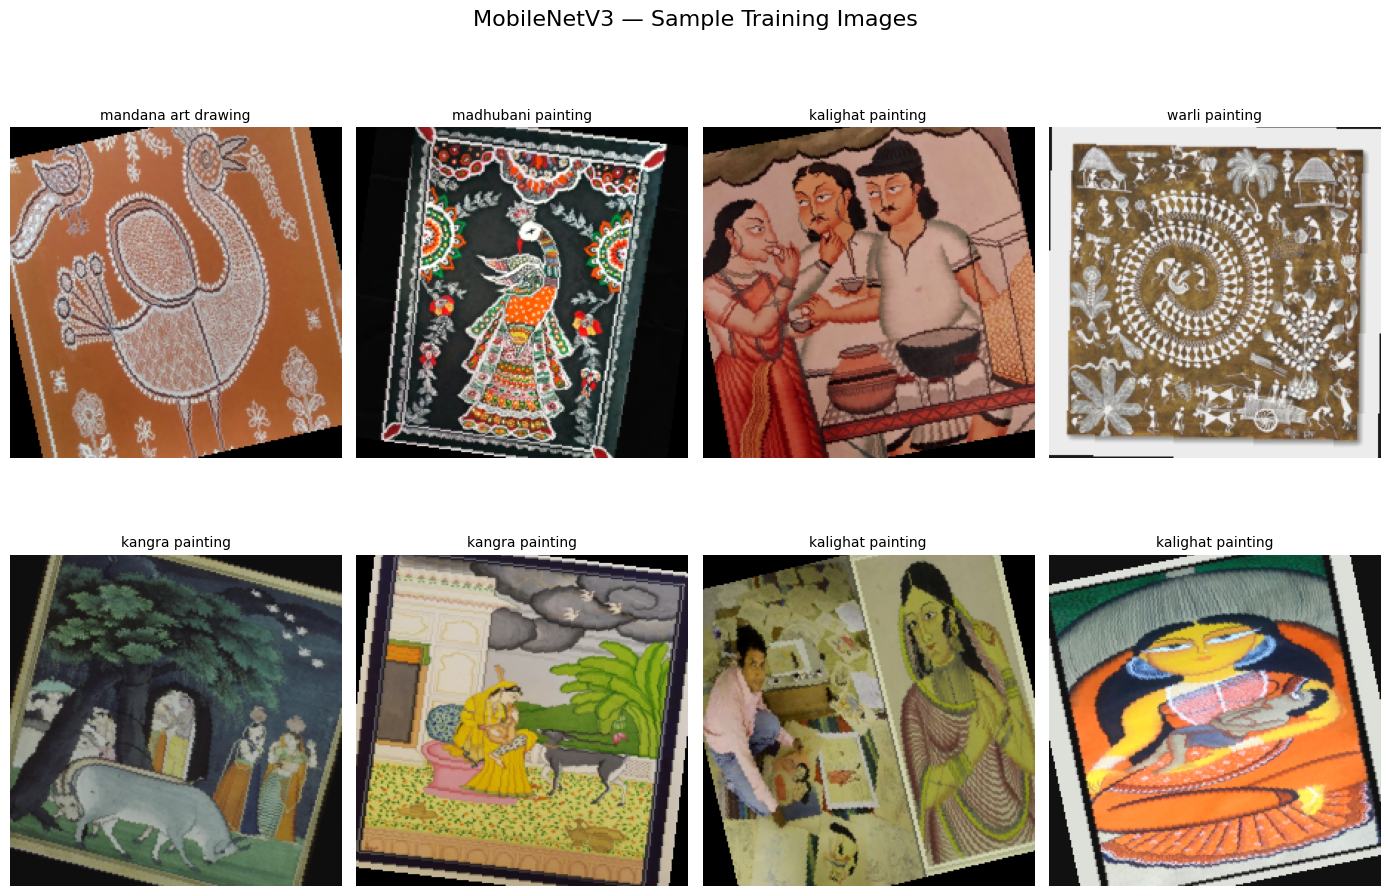

SAMPLE IMAGE VISUALIZATION COMPLETE


In [ ]:
# ============================================================
# CELL 7 — MOBILENETV3
# Visualize Sample Training Images
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Get one batch
# ------------------------------------------------------------

images, labels_batch = next(iter(train_loader))

# ------------------------------------------------------------
# Create inverse normalization
# ------------------------------------------------------------

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

# ------------------------------------------------------------
# Display images
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

num_images = min(8, len(images))

for i in range(num_images):

    image = images[i].cpu()

    # Undo ImageNet normalization
    image = image * std + mean

    # Keep values in valid range
    image = torch.clamp(image, 0, 1)

    # Convert CHW -> HWC
    image = image.permute(1, 2, 0).numpy()

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    class_index = labels_batch[i].item()

    plt.title(
        class_names[class_index],
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "MobileNetV3 — Sample Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

print("=" * 75)
print("SAMPLE IMAGE VISUALIZATION COMPLETE")
print("=" * 75)

In [ ]:
# ============================================================
# CELL 8 — MOBILENETV3
# Load Pretrained MobileNetV3-Large
# ============================================================

print("=" * 75)
print("MOBILENETV3 — LOADING PRETRAINED MODEL")
print("=" * 75)

# ------------------------------------------------------------
# Load ImageNet pretrained MobileNetV3-Large
# ------------------------------------------------------------

weights = MobileNet_V3_Large_Weights.DEFAULT

model = models.mobilenet_v3_large(
    weights=weights
)

print("\nPretrained MobileNetV3-Large loaded successfully.")

# ------------------------------------------------------------
# Inspect Original Classifier
# ------------------------------------------------------------

print("\nOriginal classifier:")
print(model.classifier)

# ------------------------------------------------------------
# Get input features of final layer
# ------------------------------------------------------------

in_features = model.classifier[-1].in_features

print(f"\nOriginal classifier input features: {in_features}")

# ------------------------------------------------------------
# Replace final classification layer
# ------------------------------------------------------------

model.classifier[-1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

# ------------------------------------------------------------
# Move model to device
# ------------------------------------------------------------

model = model.to(DEVICE)

# ------------------------------------------------------------
# Display Modified Classifier
# ------------------------------------------------------------

print("\nModified classifier:")
print(model.classifier)

print("\nNumber of output classes:", NUM_CLASSES)
print("Device:", DEVICE)

print("\n" + "=" * 75)
print("MOBILENETV3-LARGE READY FOR FINE-TUNING")
print("=" * 75)

MOBILENETV3 — LOADING PRETRAINED MODEL
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 114MB/s]



Pretrained MobileNetV3-Large loaded successfully.

Original classifier:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)

Original classifier input features: 1280

Modified classifier:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=8, bias=True)
)

Number of output classes: 8
Device: cuda

MOBILENETV3-LARGE READY FOR FINE-TUNING


In [ ]:
# ============================================================
# CELL 9 — MOBILENETV3
# Freeze Backbone & Configure Stage 1
# ============================================================

print("=" * 75)
print("MOBILENETV3 — STAGE 1 CONFIGURATION")
print("=" * 75)

# ------------------------------------------------------------
# Freeze MobileNetV3 feature extractor
# ------------------------------------------------------------

for param in model.features.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# Keep classifier trainable
# ------------------------------------------------------------

for param in model.classifier.parameters():
    param.requires_grad = True

# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

total_parameters = sum(
    param.numel()
    for param in model.parameters()
)

trainable_parameters = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)

# ------------------------------------------------------------
# Loss function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# Stage 1 Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("\nBackbone status:")
print("  MobileNetV3 features : FROZEN")
print("  Classifier           : TRAINABLE")

print("\nParameters:")
print(f"  Total parameters     : {total_parameters:,}")
print(f"  Trainable parameters : {trainable_parameters:,}")

print("\nTraining:")
print(f"  Stage 1 epochs       : {STAGE1_EPOCHS}")
print(f"  Learning rate        : {STAGE1_LR}")
print(f"  Weight decay         : {WEIGHT_DECAY}")
print(f"  Loss function        : CrossEntropyLoss")
print(f"  Optimizer            : AdamW")
print(f"  Scheduler            : ReduceLROnPlateau")

print("\n" + "=" * 75)
print("STAGE 1 CONFIGURATION READY")
print("=" * 75)

MOBILENETV3 — STAGE 1 CONFIGURATION

Backbone status:
  MobileNetV3 features : FROZEN
  Classifier           : TRAINABLE

Parameters:
  Total parameters     : 4,212,280
  Trainable parameters : 1,240,328

Training:
  Stage 1 epochs       : 5
  Learning rate        : 0.001
  Weight decay         : 0.0001
  Loss function        : CrossEntropyLoss
  Optimizer            : AdamW
  Scheduler            : ReduceLROnPlateau

STAGE 1 CONFIGURATION READY


In [ ]:
# ============================================================
# CELL 10 — MOBILENETV3
# Training & Validation Functions
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    epoch_start = time.time()

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad(set_to_none=True)

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        # ----------------------------------------------------
        # Backward pass
        # ----------------------------------------------------

        loss.backward()

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    epoch_time = time.time() - epoch_start

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_time
    )


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(model, loader, criterion, device):
    """
    Evaluate the model on the validation set.
    """

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    epoch_start = time.time()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            # ------------------------------------------------
            # Statistics
            # ------------------------------------------------

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    epoch_time = time.time() - epoch_start

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_time,
        all_labels,
        all_predictions
    )


print("=" * 75)
print("MOBILENETV3 — TRAINING FUNCTIONS")
print("=" * 75)

print("\n✓ train_one_epoch() defined")
print("✓ validate_one_epoch() defined")

print("\nTraining functions are ready.")
print("=" * 75)

MOBILENETV3 — TRAINING FUNCTIONS

✓ train_one_epoch() defined
✓ validate_one_epoch() defined

Training functions are ready.


In [ ]:
# ============================================================
# CELL 11 — MOBILENETV3
# STAGE 1 TRAINING — CLASSIFIER ONLY
# ============================================================

print("=" * 75)
print("MOBILENETV3 — STAGE 1 TRAINING")
print("=" * 75)

# ------------------------------------------------------------
# History containers
# ------------------------------------------------------------

stage1_train_losses = []
stage1_train_accuracies = []

stage1_val_losses = []
stage1_val_accuracies = []

stage1_epoch_times = []

best_stage1_val_accuracy = 0.0
best_stage1_epoch = 0

best_stage1_model_state = copy.deepcopy(
    model.state_dict()
)

# ------------------------------------------------------------
# Start Stage 1 timer
# ------------------------------------------------------------

stage1_start_time = time.time()

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(STAGE1_EPOCHS):

    epoch_number = epoch + 1

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss, train_accuracy, train_time = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    (
        val_loss,
        val_accuracy,
        val_time,
        _,
        _
    ) = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(val_accuracy)

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    stage1_train_losses.append(train_loss)
    stage1_train_accuracies.append(train_accuracy)

    stage1_val_losses.append(val_loss)
    stage1_val_accuracies.append(val_accuracy)

    stage1_epoch_times.append(
        train_time + val_time
    )

    # --------------------------------------------------------
    # Save best Stage 1 model
    # --------------------------------------------------------

    if val_accuracy > best_stage1_val_accuracy:

        best_stage1_val_accuracy = val_accuracy
        best_stage1_epoch = epoch_number

        best_stage1_model_state = copy.deepcopy(
            model.state_dict()
        )

    # --------------------------------------------------------
    # Display epoch results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch_number:02d}/{STAGE1_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}% | "
        f"Time: {train_time + val_time:.2f}s"
    )

# ------------------------------------------------------------
# Stage 1 total training time
# ------------------------------------------------------------

stage1_total_time = time.time() - stage1_start_time

# ------------------------------------------------------------
# Restore best Stage 1 model
# ------------------------------------------------------------

model.load_state_dict(
    best_stage1_model_state
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STAGE 1 TRAINING COMPLETE")
print("=" * 75)

print(
    f"\nBest Stage 1 validation accuracy : "
    f"{best_stage1_val_accuracy * 100:.2f}%"
)

print(
    f"Best Stage 1 epoch               : "
    f"{best_stage1_epoch}"
)

print(
    f"Stage 1 total training time      : "
    f"{stage1_total_time:.2f} seconds"
)

print("=" * 75)

MOBILENETV3 — STAGE 1 TRAINING


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/5] | Train Loss: 1.3344 | Train Acc: 54.59% | Val Loss: 1.1085 | Val Acc: 57.34% | Time: 22.01s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/5] | Train Loss: 0.6184 | Train Acc: 80.75% | Val Loss: 1.1965 | Val Acc: 59.44% | Time: 19.82s


...

Epoch [03/5] | Train Loss: 0.4738 | Train Acc: 83.91% | Val Loss: 0.7896 | Val Acc: 74.13% | Time: 21.11s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [04/5] | Train Loss: 0.3472 | Train Acc: 89.32% | Val Loss: 0.5729 | Val Acc: 81.82% | Time: 19.70s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [05/5] | Train Loss: 0.2817 | Train Acc: 91.13% | Val Loss: 0.6693 | Val Acc: 81.82% | Time: 21.22s

STAGE 1 TRAINING COMPLETE

Best Stage 1 validation accuracy : 81.82%
Best Stage 1 epoch               : 4
Stage 1 total training time      : 103.98 seconds


In [ ]:
# ============================================================
# CELL 12 — MOBILENETV3
# STAGE 2 CONFIGURATION — FULL FINE-TUNING
# ============================================================

print("=" * 75)
print("MOBILENETV3 — STAGE 2 CONFIGURATION")
print("=" * 75)

# ------------------------------------------------------------
# Unfreeze entire model
# ------------------------------------------------------------

for param in model.parameters():
    param.requires_grad = True

# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

total_parameters = sum(
    param.numel()
    for param in model.parameters()
)

trainable_parameters = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)

# ------------------------------------------------------------
# Stage 2 optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.parameters(),
    lr=STAGE2_LR,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Stage 2 scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("\nBackbone status:")
print("  MobileNetV3 features : TRAINABLE")
print("  Classifier           : TRAINABLE")

print("\nParameters:")
print(f"  Total parameters     : {total_parameters:,}")
print(f"  Trainable parameters : {trainable_parameters:,}")

print("\nStage 2 training:")
print(f"  Epochs               : {STAGE2_EPOCHS}")
print(f"  Learning rate        : {STAGE2_LR}")
print(f"  Weight decay         : {WEIGHT_DECAY}")
print(f"  Optimizer            : AdamW")
print(f"  Scheduler            : ReduceLROnPlateau")

print("\n" + "=" * 75)
print("STAGE 2 CONFIGURATION READY")
print("=" * 75)

MOBILENETV3 — STAGE 2 CONFIGURATION

Backbone status:
  MobileNetV3 features : TRAINABLE
  Classifier           : TRAINABLE

Parameters:
  Total parameters     : 4,212,280
  Trainable parameters : 4,212,280

Stage 2 training:
  Epochs               : 15
  Learning rate        : 0.0001
  Weight decay         : 0.0001
  Optimizer            : AdamW
  Scheduler            : ReduceLROnPlateau

STAGE 2 CONFIGURATION READY


In [ ]:
# ============================================================
# CELL 13 — MOBILENETV3
# STAGE 2 TRAINING — FULL FINE-TUNING
# ============================================================

print("=" * 75)
print("MOBILENETV3 — STAGE 2 FULL FINE-TUNING")
print("=" * 75)

# ------------------------------------------------------------
# History containers
# ------------------------------------------------------------

stage2_train_losses = []
stage2_train_accuracies = []

stage2_val_losses = []
stage2_val_accuracies = []

stage2_epoch_times = []

best_stage2_val_accuracy = best_stage1_val_accuracy
best_stage2_epoch = 0

# Start with the best model obtained from Stage 1
best_stage2_model_state = copy.deepcopy(
    model.state_dict()
)

# ------------------------------------------------------------
# Start Stage 2 timer
# ------------------------------------------------------------

stage2_start_time = time.time()

# ------------------------------------------------------------
# Stage 2 training loop
# ------------------------------------------------------------

for epoch in range(STAGE2_EPOCHS):

    epoch_number = epoch + 1

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss, train_accuracy, train_time = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    (
        val_loss,
        val_accuracy,
        val_time,
        _,
        _
    ) = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(val_accuracy)

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    stage2_train_losses.append(train_loss)
    stage2_train_accuracies.append(train_accuracy)

    stage2_val_losses.append(val_loss)
    stage2_val_accuracies.append(val_accuracy)

    stage2_epoch_times.append(
        train_time + val_time
    )

    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if val_accuracy > best_stage2_val_accuracy:

        best_stage2_val_accuracy = val_accuracy
        best_stage2_epoch = epoch_number

        best_stage2_model_state = copy.deepcopy(
            model.state_dict()
        )

    # --------------------------------------------------------
    # Current learning rate
    # --------------------------------------------------------

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # Display epoch results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch_number:02d}/{STAGE2_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.2e} | "
        f"Time: {train_time + val_time:.2f}s"
    )

# ------------------------------------------------------------
# Stage 2 total time
# ------------------------------------------------------------

stage2_total_time = time.time() - stage2_start_time

# ------------------------------------------------------------
# Restore best overall model
# ------------------------------------------------------------

model.load_state_dict(
    best_stage2_model_state
)

# ------------------------------------------------------------
# Final training time
# ------------------------------------------------------------

total_training_time = (
    stage1_total_time +
    stage2_total_time
)

# ------------------------------------------------------------
# Determine best validation accuracy
# ------------------------------------------------------------

best_val_accuracy = max(
    best_stage1_val_accuracy,
    best_stage2_val_accuracy
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STAGE 2 TRAINING COMPLETE")
print("=" * 75)

print(
    f"\nBest validation accuracy : "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Stage 2 training time   : "
    f"{stage2_total_time:.2f} seconds"
)

print(
    f"Total training time     : "
    f"{total_training_time:.2f} seconds"
)

print(
    f"Total training epochs   : "
    f"{STAGE1_EPOCHS + STAGE2_EPOCHS}"
)

print("=" * 75)

MOBILENETV3 — STAGE 2 FULL FINE-TUNING


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/15] | Train Loss: 0.2503 | Train Acc: 90.68% | Val Loss: 0.6687 | Val Acc: 79.72% | LR: 1.00e-04 | Time: 21.14s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/15] | Train Loss: 0.1376 | Train Acc: 96.24% | Val Loss: 0.6029 | Val Acc: 83.22% | LR: 1.00e-04 | Time: 21.09s


...

Epoch [13/15] | Train Loss: 0.0069 | Train Acc: 100.00% | Val Loss: 0.4704 | Val Acc: 84.62% | LR: 5.00e-05 | Time: 22.03s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [14/15] | Train Loss: 0.0053 | Train Acc: 100.00% | Val Loss: 0.4610 | Val Acc: 86.01% | LR: 5.00e-05 | Time: 20.59s


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [15/15] | Train Loss: 0.0090 | Train Acc: 99.85% | Val Loss: 0.4715 | Val Acc: 84.62% | LR: 2.50e-05 | Time: 21.85s

STAGE 2 TRAINING COMPLETE

Best validation accuracy : 86.01%
Stage 2 training time   : 320.93 seconds
Total training time     : 424.91 seconds
Total training epochs   : 20


In [ ]:
# ============================================================
# CELL 14 — MOBILENETV3
# FINAL TEST SET EVALUATION
# ============================================================

print("=" * 75)
print("MOBILENETV3 — FINAL TEST EVALUATION")
print("=" * 75)

# ------------------------------------------------------------
# Evaluate best model on test set
# ------------------------------------------------------------

(
    test_loss,
    test_accuracy_raw,
    test_time,
    test_true_labels,
    test_predictions
) = validate_one_epoch(
    model,
    test_loader,
    criterion,
    DEVICE
)

# ------------------------------------------------------------
# Convert to NumPy arrays
# ------------------------------------------------------------

test_true_labels = np.array(test_true_labels)
test_predictions = np.array(test_predictions)

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

macro_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nTEST RESULTS")
print("-" * 75)

print(f"Test Loss          : {test_loss:.4f}")
print(f"Test Accuracy      : {test_accuracy * 100:.2f}%")
print(f"Macro Precision    : {macro_precision * 100:.2f}%")
print(f"Macro Recall       : {macro_recall * 100:.2f}%")
print(f"Macro F1           : {macro_f1 * 100:.2f}%")
print(f"Weighted F1        : {weighted_f1 * 100:.2f}%")

print(f"\nTest samples       : {len(test_true_labels)}")

print("\n" + "=" * 75)
print("FINAL TEST EVALUATION COMPLETE")
print("=" * 75)

MOBILENETV3 — FINAL TEST EVALUATION

TEST RESULTS
---------------------------------------------------------------------------
Test Loss          : 0.5653
Test Accuracy      : 83.22%
Macro Precision    : 84.69%
Macro Recall       : 81.00%
Macro F1           : 81.86%
Weighted F1        : 82.65%

Test samples       : 143

FINAL TEST EVALUATION COMPLETE


In [ ]:
# ============================================================
# CELL 15 — MOBILENETV3
# DETAILED CLASSIFICATION REPORT
# ============================================================

print("=" * 75)
print("MOBILENETV3 — DETAILED CLASSIFICATION REPORT")
print("=" * 75)

report = classification_report(
    test_true_labels,
    test_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\nCLASSIFICATION REPORT")
print("-" * 75)
print(report)

# Store report as DataFrame for later saving/comparison
report_dict = classification_report(
    test_true_labels,
    test_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report_dict).transpose()

print("=" * 75)
print("DETAILED CLASSIFICATION REPORT COMPLETE")
print("=" * 75)

MOBILENETV3 — DETAILED CLASSIFICATION REPORT

CLASSIFICATION REPORT
---------------------------------------------------------------------------
                     precision    recall  f1-score   support

      gond painting     0.8750    0.9333    0.9032        15
  kalighat painting     0.8140    0.9459    0.8750        37
    kangra painting     0.8889    0.6154    0.7273        13
       kerala mural     0.9286    0.9286    0.9286        14
 madhubani painting     0.7500    0.8571    0.8000        14
mandana art drawing     0.7727    0.8095    0.7907        21
   pichwai painting     0.8889    0.5333    0.6667        15
     warli painting     0.8571    0.8571    0.8571        14

           accuracy                         0.8322       143
          macro avg     0.8469    0.8100    0.8186       143
       weighted avg     0.8382    0.8322    0.8265       143

DETAILED CLASSIFICATION REPORT COMPLETE


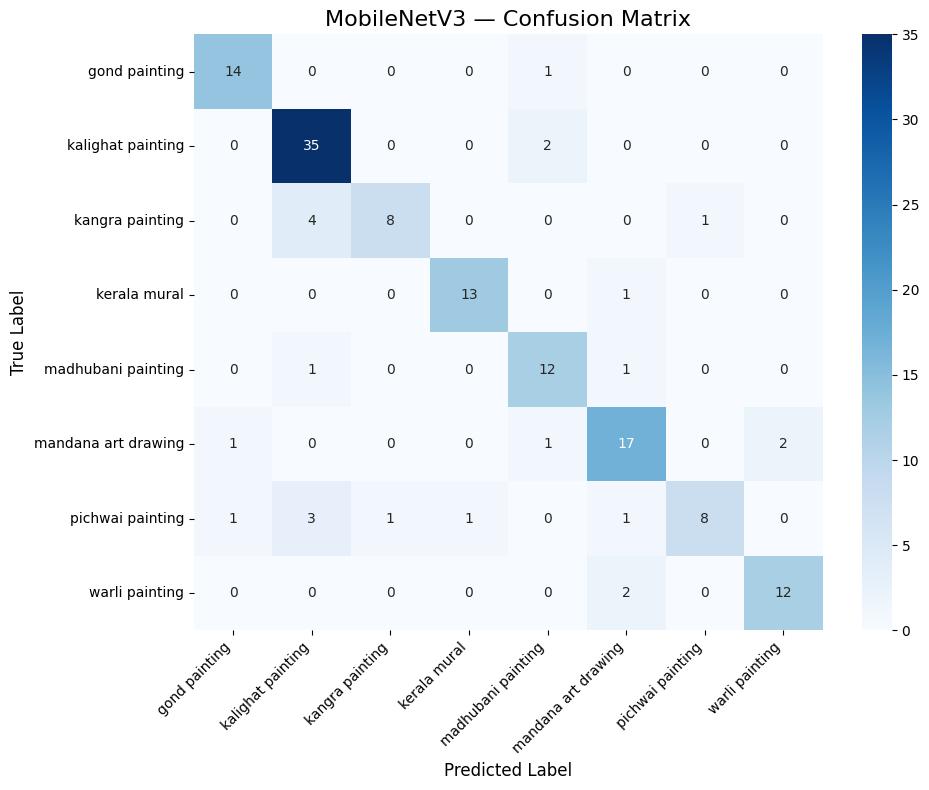

MOBILENETV3 — CONFUSION MATRIX

Rows    = True Classes
Columns = Predicted Classes

Confusion Matrix:
[[14  0  0  0  1  0  0  0]
 [ 0 35  0  0  2  0  0  0]
 [ 0  4  8  0  0  0  1  0]
 [ 0  0  0 13  0  1  0  0]
 [ 0  1  0  0 12  1  0  0]
 [ 1  0  0  0  1 17  0  2]
 [ 1  3  1  1  0  1  8  0]
 [ 0  0  0  0  0  2  0 12]]

CONFUSION MATRIX COMPLETE


In [ ]:
# ============================================================
# CELL 16 — MOBILENETV3
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("MobileNetV3 — Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("=" * 75)
print("MOBILENETV3 — CONFUSION MATRIX")
print("=" * 75)

print("\nRows    = True Classes")
print("Columns = Predicted Classes")

print("\nConfusion Matrix:")
print(cm)

print("\n" + "=" * 75)
print("CONFUSION MATRIX COMPLETE")
print("=" * 75)

In [ ]:
# ============================================================
# CELL 17 — MOBILENETV3
# CHECK AVAILABLE TRAINING HISTORY VARIABLES
# ============================================================

print("=" * 75)
print("MOBILENETV3 — CHECKING TRAINING HISTORY")
print("=" * 75)

history_variables = []

# Take a snapshot so globals() cannot change during iteration
global_items = list(globals().items())

for name, value in global_items:
    name_lower = name.lower()

    if (
        "history" in name_lower
        or "train_loss" in name_lower
        or "val_loss" in name_lower
        or "train_acc" in name_lower
        or "val_acc" in name_lower
    ):
        history_variables.append(name)

print("\nPossible training-history variables found:")

if history_variables:
    for name in sorted(set(history_variables)):
        value = globals().get(name)
        print(f"  {name:<35} {type(value).__name__}")
else:
    print("  No training-history variables found.")

print("\n" + "=" * 75)
print("HISTORY VARIABLE CHECK COMPLETE")
print("=" * 75)

MOBILENETV3 — CHECKING TRAINING HISTORY

Possible training-history variables found:
  best_stage1_val_accuracy            float
  best_stage2_val_accuracy            float
  best_val_accuracy                   float
  history_variables                   list
  stage1_train_accuracies             list
  stage1_train_losses                 list
  stage1_val_accuracies               list
  stage1_val_losses                   list
  stage2_train_accuracies             list
  stage2_train_losses                 list
  stage2_val_accuracies               list
  stage2_val_losses                   list
  train_accuracy                      float
  train_loss                          float
  val_accuracy                        float
  val_loss                            float

HISTORY VARIABLE CHECK COMPLETE


MOBILENETV3 — TRAINING CURVES


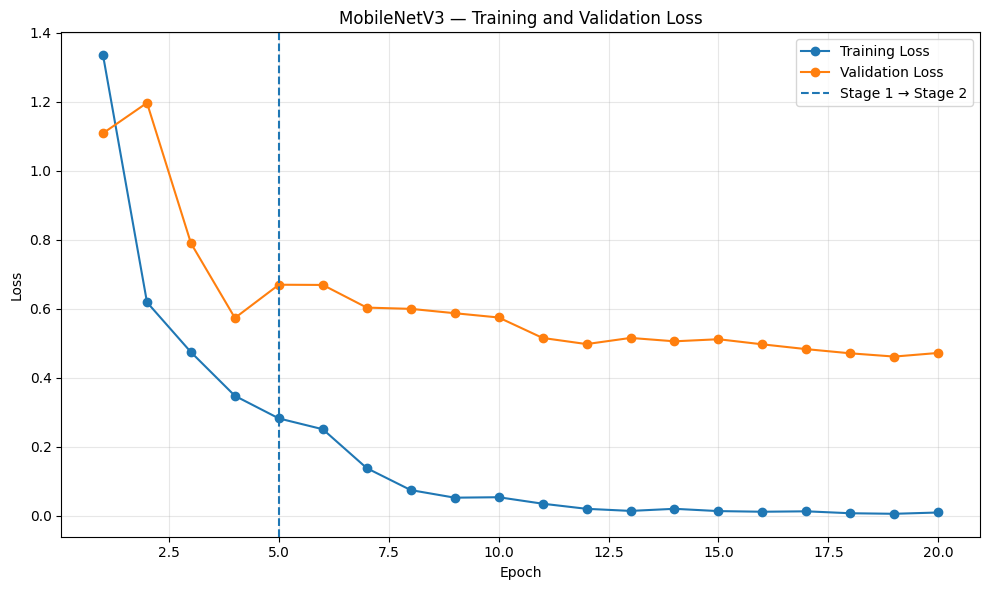

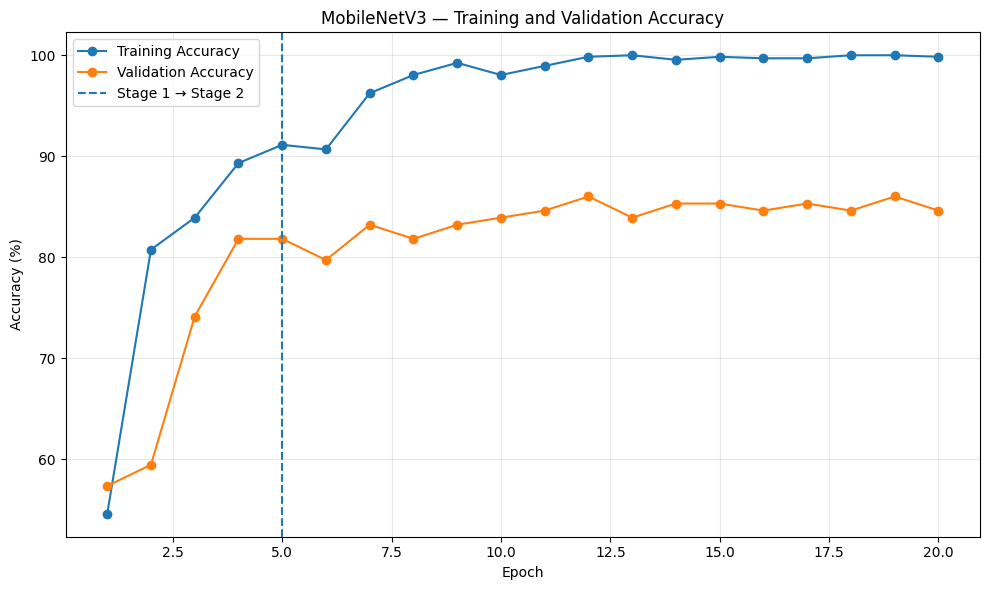


TRAINING SUMMARY
---------------------------------------------------------------------------
Stage 1 epochs            : 5
Stage 2 epochs            : 15
Total epochs              : 20
Best validation accuracy  : 86.01%
Best validation epoch     : 12

TRAINING CURVES COMPLETE


In [ ]:
# ============================================================
# CELL 18 — MOBILENETV3
# COMBINED TRAINING CURVES
# ============================================================

print("=" * 75)
print("MOBILENETV3 — TRAINING CURVES")
print("=" * 75)

# ------------------------------------------------------------
# Combine Stage 1 + Stage 2 histories
# ------------------------------------------------------------

combined_train_losses = (
    stage1_train_losses + stage2_train_losses
)

combined_val_losses = (
    stage1_val_losses + stage2_val_losses
)

combined_train_accuracies = (
    stage1_train_accuracies + stage2_train_accuracies
)

combined_val_accuracies = (
    stage1_val_accuracies + stage2_val_accuracies
)

epochs = range(1, len(combined_train_losses) + 1)

# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    combined_train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    combined_val_losses,
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=STAGE1_EPOCHS,
    linestyle="--",
    label="Stage 1 → Stage 2"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV3 — Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    np.array(combined_train_accuracies) * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    np.array(combined_val_accuracies) * 100,
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=STAGE1_EPOCHS,
    linestyle="--",
    label="Stage 1 → Stage 2"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("MobileNetV3 — Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# BEST VALIDATION RESULT
# ------------------------------------------------------------

best_epoch = int(np.argmax(combined_val_accuracies)) + 1
best_curve_val_accuracy = max(combined_val_accuracies)

print("\nTRAINING SUMMARY")
print("-" * 75)
print(f"Stage 1 epochs            : {len(stage1_train_losses)}")
print(f"Stage 2 epochs            : {len(stage2_train_losses)}")
print(f"Total epochs              : {len(combined_train_losses)}")
print(f"Best validation accuracy  : {best_curve_val_accuracy * 100:.2f}%")
print(f"Best validation epoch     : {best_epoch}")

print("\n" + "=" * 75)
print("TRAINING CURVES COMPLETE")
print("=" * 75)

In [ ]:
# ============================================================
# CELL 19 — MOBILENETV3
# MODEL PARAMETERS & MODEL SIZE
# ============================================================

print("=" * 75)
print("MOBILENETV3 — MODEL PARAMETERS & SIZE")
print("=" * 75)

# ------------------------------------------------------------
# Parameter counts
# ------------------------------------------------------------

total_parameters = sum(
    param.numel()
    for param in model.parameters()
)

trainable_parameters = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)

non_trainable_parameters = (
    total_parameters - trainable_parameters
)

# ------------------------------------------------------------
# Model memory size based on parameters
# ------------------------------------------------------------

model_size_bytes = sum(
    param.numel() * param.element_size()
    for param in model.parameters()
)

model_size_mb = model_size_bytes / (1024 ** 2)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nMODEL INFORMATION")
print("-" * 75)

print(f"Model architecture       : {MODEL_NAME}")
print(f"Number of classes        : {NUM_CLASSES}")
print(f"Input resolution         : {IMAGE_SIZE} × {IMAGE_SIZE}")

print("\nPARAMETERS")
print("-" * 75)

print(f"Total parameters         : {total_parameters:,}")
print(f"Trainable parameters     : {trainable_parameters:,}")
print(f"Non-trainable parameters : {non_trainable_parameters:,}")

print("\nMODEL SIZE")
print("-" * 75)

print(f"Model size               : {model_size_mb:.2f} MB")
print(f"Model size               : {model_size_bytes:,} bytes")

print("\n" + "=" * 75)
print("MODEL PARAMETERS & SIZE COMPLETE")
print("=" * 75)

MOBILENETV3 — MODEL PARAMETERS & SIZE

MODEL INFORMATION
---------------------------------------------------------------------------
Model architecture       : MobileNetV3-Large
Number of classes        : 8
Input resolution         : 224 × 224

PARAMETERS
---------------------------------------------------------------------------
Total parameters         : 4,212,280
Trainable parameters     : 4,212,280
Non-trainable parameters : 0

MODEL SIZE
---------------------------------------------------------------------------
Model size               : 16.07 MB
Model size               : 16,849,120 bytes

MODEL PARAMETERS & SIZE COMPLETE


In [ ]:
# ============================================================
# CELL 20 — MOBILENETV3
# INFERENCE TIME & THROUGHPUT
# ============================================================

print("=" * 75)
print("MOBILENETV3 — INFERENCE PERFORMANCE")
print("=" * 75)

model.eval()

# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

warmup_batches = 5
warmup_count = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE, non_blocking=True)

        _ = model(images)

        warmup_count += 1

        if warmup_count >= warmup_batches:
            break

# Synchronize GPU before timing
if torch.cuda.is_available():
    torch.cuda.synchronize()

# ------------------------------------------------------------
# Timed inference
# ------------------------------------------------------------

total_images = 0

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_start = time.perf_counter()

with torch.no_grad():
    for images, _ in test_loader:

        images = images.to(DEVICE, non_blocking=True)

        _ = model(images)

        total_images += images.size(0)

if torch.cuda.is_available():
    torch.cuda.synchronize()

inference_end = time.perf_counter()

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

total_inference_time = inference_end - inference_start

avg_inference_time_ms = (
    total_inference_time / total_images
) * 1000

inference_throughput = (
    total_images / total_inference_time
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nINFERENCE RESULTS")
print("-" * 75)

print(f"Device                    : {DEVICE}")
print(f"Test images processed     : {total_images}")
print(f"Total inference time      : {total_inference_time:.4f} seconds")
print(f"Average inference time    : {avg_inference_time_ms:.4f} ms/image")
print(f"Inference throughput      : {inference_throughput:.2f} images/sec")

print("\n" + "=" * 75)
print("INFERENCE PERFORMANCE COMPLETE")
print("=" * 75)

MOBILENETV3 — INFERENCE PERFORMANCE

INFERENCE RESULTS
---------------------------------------------------------------------------
Device                    : cuda
Test images processed     : 143
Total inference time      : 3.1622 seconds
Average inference time    : 22.1135 ms/image
Inference throughput      : 45.22 images/sec

INFERENCE PERFORMANCE COMPLETE


In [ ]:
# ============================================================
# CELL 21 — MOBILENETV3
# SAVE BEST MODEL & FINAL SUMMARY
# ============================================================

print("=" * 75)
print("MOBILENETV3 — SAVING FINAL MODEL")
print("=" * 75)

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

final_metrics = {
    "Model": MODEL_NAME,
    "Classes": NUM_CLASSES,
    "Input Size": f"{IMAGE_SIZE}x{IMAGE_SIZE}",

    "Test Accuracy (%)": test_accuracy * 100,
    "Macro Precision (%)": macro_precision * 100,
    "Macro Recall (%)": macro_recall * 100,
    "Macro F1 (%)": macro_f1 * 100,
    "Weighted F1 (%)": weighted_f1 * 100,

    "Best Validation Accuracy (%)": best_val_accuracy * 100,
    "Best Validation Epoch": best_epoch,

    "Total Parameters": total_parameters,
    "Trainable Parameters": trainable_parameters,
    "Non-trainable Parameters": non_trainable_parameters,

    "Model Size (MB)": model_size_mb,

    "Stage 1 Epochs": len(stage1_train_losses),
    "Stage 2 Epochs": len(stage2_train_losses),
    "Total Epochs": len(combined_train_losses),

    "Stage 1 Training Time (sec)": stage1_total_time,
    "Stage 2 Training Time (sec)": stage2_total_time,
    "Total Training Time (sec)": total_training_time,
    "Total Training Time (min)": total_training_time / 60,

    "Total Inference Time (sec)": total_inference_time,
    "Average Inference Time (ms/image)": avg_inference_time_ms,
    "Inference Throughput (images/sec)": inference_throughput
}

# ------------------------------------------------------------
# Save model checkpoint
# ------------------------------------------------------------

model_path = os.path.join(
    DRIVE_SAVE_PATH,
    "MobileNetV3_Large_Final.pth"
)

checkpoint = {
    "model_name": MODEL_NAME,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "image_size": IMAGE_SIZE,

    "model_state_dict": model.state_dict(),

    "best_validation_accuracy": best_val_accuracy,
    "best_validation_epoch": best_epoch,

    "test_accuracy": test_accuracy,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,

    "total_parameters": total_parameters,
    "trainable_parameters": trainable_parameters,
    "model_size_mb": model_size_mb,

    "total_epochs": len(combined_train_losses),
    "total_training_time_seconds": total_training_time,

    "average_inference_time_ms": avg_inference_time_ms,
    "inference_throughput": inference_throughput,

    "seed": SEED
}

torch.save(checkpoint, model_path)

# ------------------------------------------------------------
# Save final metrics as CSV
# ------------------------------------------------------------

summary_df = pd.DataFrame(
    [final_metrics]
)

summary_csv_path = os.path.join(
    DRIVE_SAVE_PATH,
    "MobileNetV3_Final_Summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)

# ------------------------------------------------------------
# Save classification report
# ------------------------------------------------------------

classification_csv_path = os.path.join(
    DRIVE_SAVE_PATH,
    "MobileNetV3_Classification_Report.csv"
)

classification_report_df.to_csv(
    classification_csv_path
)

# ------------------------------------------------------------
# Print final summary
# ------------------------------------------------------------

print("\nFINAL MODEL SUMMARY")
print("-" * 75)

for key, value in final_metrics.items():
    if isinstance(value, float):
        print(f"{key:<40}: {value:.4f}")
    else:
        print(f"{key:<40}: {value}")

print("\nSAVED FILES")
print("-" * 75)
print(f"Model checkpoint : {model_path}")
print(f"Summary CSV      : {summary_csv_path}")
print(f"Classification   : {classification_csv_path}")

print("\n" + "=" * 75)
print("MOBILENETV3 MODEL SAVED SUCCESSFULLY")
print("=" * 75)

MOBILENETV3 — SAVING FINAL MODEL

FINAL MODEL SUMMARY
---------------------------------------------------------------------------
Model                                   : MobileNetV3-Large
Classes                                 : 8
Input Size                              : 224x224
Test Accuracy (%)                       : 83.2168
Macro Precision (%)                     : 84.6897
Macro Recall (%)                        : 81.0047
Macro F1 (%)                            : 81.8572
Weighted F1 (%)                         : 82.6452
Best Validation Accuracy (%)            : 86.0140
Best Validation Epoch                   : 12
Total Parameters                        : 4212280
Trainable Parameters                    : 4212280
Non-trainable Parameters                : 0
Model Size (MB)                         : 16.0686
Stage 1 Epochs                          : 5
Stage 2 Epochs                          : 15
Total Epochs                            : 20
Stage 1 Training Time (sec)             : 1